# MobileNetV3 NYU Depth V2 Fine-tuning (TensorFlow/Keras)
### Fine-tune backbone on NYU Depth V2 (scene classification) → export to TFLite for teammates

**Steps:** Download data → Load MobileNetV3 → 3-stage fine-tuning → Save backbone weights + TFLite

**Fine-tuning strategy:**
```
# Stage | Layers unfrozen         | Learning rate |
# ------+-------------------------+---------------+
#   0   | head only               |    1e-3       |  
#   1   | top 20 backbone layers  |    5e-5       |  
#   2   | top 50 backbone layers  |    2e-5       |  
#   3   | entire backbone         |    5e-6       |  
```

> **Before running:** Runtime → Change runtime type → T4 GPU

## Cell 1 — Imports & Setup

In [ ]:
import os, time, random, shutil, zipfile, h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPUs available     : {len(gpus)}')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU                : {gpus[0].name}')

SEED       = 42
IMG_SIZE   = 224
BATCH_SIZE = 32
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow version : 2.19.0
GPUs available     : 0


## Cell 2 — Download NYU Depth V2 Dataset

NYU Depth V2 is distributed as a single `.mat` HDF5 file (~2.8 GB) containing
RGB images and their scene-type labels. We download it, extract the RGB frames
and integer scene labels, then save them into a folder-per-class structure that
`image_dataset_from_directory` can consume.

In [ ]:
# ── Download ──────────────────────────────────────────────────────────────────
# Official mirror (NYU Depth Dataset V2, labeled subset, ~2.8 GB)
!wget -q --show-progress -O nyu_depth_v2_labeled.mat \
    http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat

print('Download complete. Inspecting .mat file structure...')
with h5py.File('nyu_depth_v2_labeled.mat', 'r') as f:
    print('Top-level keys:', list(f.keys()))
    # 'images'       : (3, H, W, N)  uint8  RGB
    # 'sceneTypes'   : (1, N)        cell   scene-label strings
    # 'labels'       : (H, W, N)     uint16 pixel labels (not used here)
    print('images shape  :', f['images'].shape)
    print('sceneTypes shape:', f['sceneTypes'].shape)

nyu_depth_v2_labele 100%[===================>]   2.77G  52.8MB/s    in 55s     
Download complete. Inspecting .mat file structure...
Top-level keys: ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']
images shape  : (1449, 3, 640, 480)
sceneTypes shape: (1, 1449)


In [ ]:
import cv2, os, h5py, numpy as np
from tqdm import tqdm

DATA_DIR = "nyu_depth_v2/images"
os.makedirs(DATA_DIR, exist_ok=True)

with h5py.File("nyu_depth_v2_labeled.mat", "r") as f:

    print("Loading RGB tensor to RAM (this is the key fix)...")
    all_imgs = np.array(f["images"])          # (3, 480, 640, N)  ~1.3GB
    scene_refs = f["sceneTypes"][0]
    N = all_imgs.shape[3]

    print("Decoding scene names...")
    scene_names = []
    for i in range(N):
        scene_bytes = f[scene_refs[i]][()]
        name = "".join(chr(c) for c in scene_bytes.flatten())
        name = name.strip().replace("/", "_").replace(" ", "_")
        scene_names.append(name)

print("✅ Loaded everything to RAM")

# create folders once
for s in set(scene_names):
    os.makedirs(os.path.join(DATA_DIR, s), exist_ok=True)

# extract fast
for i in tqdm(range(N)):
    img = all_imgs[:, :, :, i]          # (3, H, W)
    img = img.transpose(2, 1, 0)        # (W, H, 3) — fix column-major order
    img = np.rot90(img, k=-1)           # rotate to upright
    img = np.ascontiguousarray(img).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    out_path = os.path.join(DATA_DIR, scene_names[i], f"{i:05d}.jpg")
    cv2.imwrite(out_path, img, [cv2.IMWRITE_JPEG_QUALITY, 95])

# stats
categories  = sorted(os.listdir(DATA_DIR))
NUM_CLASSES = len(categories)
total_imgs  = sum(len(os.listdir(os.path.join(DATA_DIR, c))) for c in categories)

print(f"\nTotal categories : {NUM_CLASSES}")
print(f"Total images     : {total_imgs}")
print(f"Classes          : {categories}")

Loading RGB tensor to RAM (this is the key fix)...
Decoding scene names...
✅ Loaded everything to RAM


100%|██████████| 480/480 [00:22<00:00, 20.91it/s]


Total categories : 24
Total images     : 480
Classes          : ['bathroom', 'bedroom', 'bookstore', 'cafe', 'classroom', 'computer_lab', 'conference_room', 'dinette', 'excercise_room', 'foyer', 'furniture_store', 'home_office', 'home_storage', 'indoor_balcony', 'kitchen', 'laundry_room', 'living_room', 'office', 'office_kitchen', 'playroom', 'printer_room', 'reception_room', 'study', 'study_room']


## Cell 3 — Extract Images into Folder-per-Class Structure

In [ ]:
import h5py
import numpy as np

MAT_FILE = "nyu_depth_v2_labeled.mat"

with h5py.File("nyu_depth_v2_labeled.mat", "r") as f:
    print("Loading RGB tensor to RAM...")
    all_imgs = np.array(f["images"])       # (1449, 3, 640, 480)
    scene_refs = f["sceneTypes"][0]
    N = all_imgs.shape[0]                  # ← fixed

    print("Decoding scene names...")
    scene_names = []
    for i in range(N):
        scene_bytes = f[scene_refs[i]][()]
        name = "".join(chr(c) for c in scene_bytes.flatten())
        name = name.strip().replace("/", "_").replace(" ", "_")
        scene_names.append(name)

for s in set(scene_names):
    os.makedirs(os.path.join(DATA_DIR, s), exist_ok=True)

for i in tqdm(range(N)):
    img = all_imgs[i, :, :, :]      # (3, 640, 480)
    img = img.transpose(2, 1, 0)    # (480, 640, 3)
    img = np.ascontiguousarray(img).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    out_path = os.path.join(DATA_DIR, scene_names[i], f"{i:05d}.jpg")
    cv2.imwrite(out_path, img, [cv2.IMWRITE_JPEG_QUALITY, 95])

print("✅ Loaded everything into RAM")
print("RGB shape:", all_imgs.shape)
print("Total scenes:", len(set(scene_names)))

Loading RGB tensor to RAM...
Decoding scene names...


100%|██████████| 1449/1449 [00:08<00:00, 170.22it/s]

✅ Loaded everything into RAM
RGB shape: (1449, 3, 640, 480)
Total scenes: 27


## Cell 4 — Build tf.data Pipelines

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load datasets using keras utility (80/20 split)
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
print(f'Class names: {class_names}')

# MobileNetV3 preprocessing (scales pixels to [-1, 1])
preprocess = keras.applications.mobilenet_v3.preprocess_input

# Augmentation layer (applied only during training)
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name='augmentation')

def prepare_train(images, labels):
    images = augment(images, training=True)
    images = preprocess(images)
    return images, labels

def prepare_val(images, labels):
    images = preprocess(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(prepare_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(prepare_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Data pipelines ready!')

Found 1449 files belonging to 27 classes.
Using 1160 files for training.
Found 1449 files belonging to 27 classes.
Using 289 files for validation.
Class names: ['basement', 'bathroom', 'bedroom', 'bookstore', 'cafe', 'classroom', 'computer_lab', 'conference_room', 'dinette', 'dining_room', 'excercise_room', 'foyer', 'furniture_store', 'home_office', 'home_storage', 'indoor_balcony', 'kitchen', 'laundry_room', 'living_room', 'office', 'office_kitchen', 'playroom', 'printer_room', 'reception_room', 'student_lounge', 'study', 'study_room']
Data pipelines ready!


## Cell 5 — Visualize Sample Images

Found 1449 files belonging to 27 classes.
Using 1160 files for training.


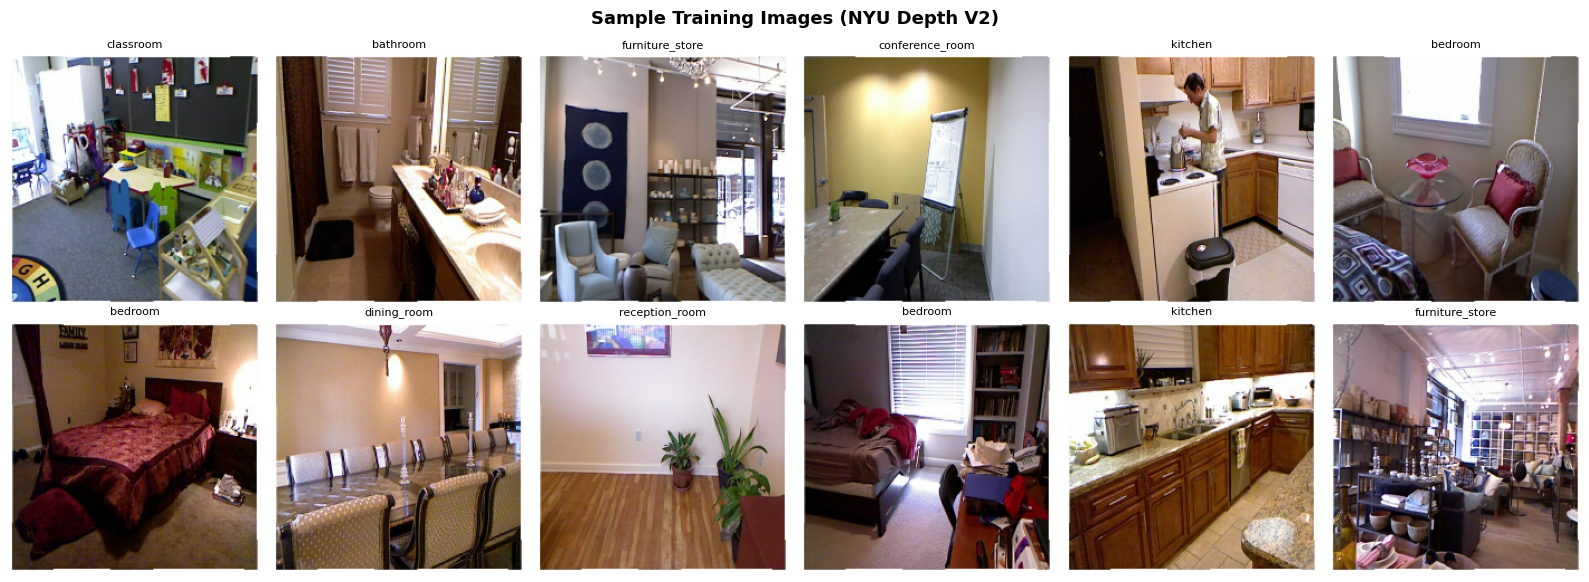

In [ ]:
# Grab one raw batch (before preprocessing) for visualization
raw_ds = image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='training',
    seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=12, label_mode='int'
)
imgs, labels = next(iter(raw_ds))

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].numpy().astype('uint8'))
    ax.set_title(class_names[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images (NYU Depth V2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Run this FIRST before the loop
sample = all_imgs[:, :, :, 0]
print("Raw sample shape:", sample.shape)
print("all_imgs full shape:", all_imgs.shape)

Raw sample shape: (1449, 3, 640)
all_imgs full shape: (1449, 3, 640, 480)


## Cell 6 — Build Model with MobileNetV3 Backbone

In [ ]:
def build_model(num_classes, backbone_trainable=False):
    """
    MobileNetV3Large backbone + custom classification head.
    backbone_trainable: whether backbone weights are frozen.
    """
    # Load pretrained MobileNetV3Small backbone (ImageNet weights, no top)
    backbone = MobileNetV3Small(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,           # remove ImageNet classifier
        weights='imagenet',
        include_preprocessing=False  # we handle preprocessing manually
    )
    backbone.trainable = backbone_trainable

    # Build full model
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)   # training=False keeps BN frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='hard_swish')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, backbone

model, backbone = build_model(NUM_CLASSES, backbone_trainable=False)

print('Model summary:')
model.summary(line_length=70)
print(f'\nBackbone layers : {len(backbone.layers)}')
print(f'Total params    : {model.count_params():,}')

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model summary:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)   │ (None, 224, 224, 3)   │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ MobileNetV3Small             │ (None, 7, 7, 576)     │     939,120 │
│ (Functional)                 │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ global_average_pooling2d_1   │ (None, 576)           │           0 │
│ (GlobalAveragePooling2D)     │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_2 (Dense)              │ (None, 256)           │     147,712 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_1 (Dropout)          │ (None, 256)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_3 (Dense)              │ (None, 24)            │       6,168 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 1,093,000 (4.17 MB)

 Trainable params: 153,880 (601.09 KB)

 Non-trainable params: 939,120 (3.58 MB)


Backbone layers : 156
Total params    : 1,093,000


## Cell 7 — History Tracker & Plot Helper

In [ ]:
all_history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
stage_boundaries = []   # cumulative epoch counts where stages change

def accumulate_history(hist):
    for key in all_history:
        all_history[key].extend(hist.history[key])
    stage_boundaries.append(len(all_history['loss']))

def plot_history():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_x = list(range(1, len(all_history['loss']) + 1))
    pairs = [('loss', 'val_loss', 'Loss'),
             ('accuracy', 'val_accuracy', 'Accuracy')]
    stage_labels = ['S0\n(head)', 'S1\n(top-20)', 'S2\n(top-50)', 'S3\n(full)']
    for ax, (tr_key, vl_key, title) in zip(axes, pairs):
        ax.plot(epochs_x, all_history[tr_key], label='Train', color='steelblue')
        ax.plot(epochs_x, all_history[vl_key], label='Val',   color='coral')
        for b in stage_boundaries[:-1]:
            ax.axvline(b + 0.5, color='gray', linestyle='--', alpha=0.6)
        for i, (start, end) in enumerate(zip(
                [0] + stage_boundaries[:-1], stage_boundaries)):
            mid  = (start + end) / 2 + 1
            ymax = max(max(all_history[tr_key]), max(all_history[vl_key]))
            label = stage_labels[i] if i < len(stage_labels) else f'S{i}'
            ax.text(mid, ymax * 0.97, label, ha='center', fontsize=8, color='gray')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('MobileNetV3 NYU Depth V2 Fine-tuning History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved to /content/training_history.png')

print('Helpers ready!')

Helpers ready!


## Cell 8 — Stage 0: Train Head Only (Backbone Fully Frozen)
Warm up the randomly-initialized classification head before touching any backbone weights.

In [ ]:
# ============================================
# GLOBAL TRAINING HISTORY STORAGE
# ============================================

GLOBAL_HISTORY = {
    "loss": [],
    "val_loss": [],
    "accuracy": [],
    "val_accuracy": [],
    "phase_lens": [],
    "phase_names": []
}

def accumulate_history(history_obj, phase_name):
    hist = history_obj.history

    GLOBAL_HISTORY["loss"].extend(hist["loss"])
    GLOBAL_HISTORY["val_loss"].extend(hist["val_loss"])
    GLOBAL_HISTORY["accuracy"].extend(hist["accuracy"])
    GLOBAL_HISTORY["val_accuracy"].extend(hist["val_accuracy"])

    GLOBAL_HISTORY["phase_lens"].append(len(hist["loss"]))
    GLOBAL_HISTORY["phase_names"].append(phase_name)

In [ ]:
STAGE0_EPOCHS = 5

# Backbone is fully frozen — only Dense head trains
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_s0 = [
    keras.callbacks.ModelCheckpoint(
        '/content/best_s0.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )
]

trainable_count = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f'Stage 0: Classifier head only | Trainable params: {trainable_count:,}')

hist_s0 = model.fit(
    train_ds,
    epochs=STAGE0_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_s0
)

accumulate_history(hist_s0, "Stage 0\n(Head only)")
model.load_weights('/content/best_s0.keras')
print(f'Stage 0 done. Best val acc: {max(hist_s0.history["val_accuracy"])*100:.1f}%')


PHASE 1 — Classifier head only  |  backbone frozen
Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.2217 - accuracy: 0.6512
Epoch 1: val_accuracy improved from inf to 0.6625
113/113 ━━━━━━━━━━━━━━━━━━━━ 44s 197ms/step - loss: 0.2209 - accuracy: 0.6564 - val_loss: 0.1914 - val_accuracy: 0.6625

Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2053 - accuracy: 0.6686
Epoch 2: val_accuracy improved to 0.6814
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2038 - accuracy: 0.6731 - val_loss: 0.1823 - val_accuracy: 0.6814

Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1951 - accuracy: 0.6847
Epoch 3: val_accuracy improved to 0.6948
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1939 - accuracy: 0.6889 - val_loss: 0.1738 - val_accuracy: 0.6948

Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1864 - accuracy: 0.6976
Epoch 4: val_accuracy improved to 0.7065
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1849 - accuracy:

## Cell 9 — Stage 1: Unfreeze Top 20 Backbone Layers  (LR = 5e-5, 8 epochs)

In [ ]:
STAGE1_LR     = 5e-5
STAGE1_EPOCHS = 8

# Unfreeze only the last 20 layers of the backbone
backbone.trainable = True
for layer in backbone.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=STAGE1_LR,
            decay_steps=STAGE1_EPOCHS * len(train_ds)
        )
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_s1 = [
    keras.callbacks.ModelCheckpoint(
        '/content/best_s1.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
    )
]

trainable_count = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f'Stage 1: Top 20 backbone layers unfrozen | LR={STAGE1_LR} | Trainable params: {trainable_count:,}')

hist_s1 = model.fit(
    train_ds,
    epochs=STAGE1_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_s1
)

accumulate_history(hist_s1, "Stage 1\n(Top 20)")
print(f'Stage 1 done. Best val acc: {max(hist_s1.history["val_accuracy"])*100:.1f}%')

PHASE 2 — Stage 1/3  |  top 20 backbone layers unfrozen  |  lr=5e-05
Epoch 1/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.1487 - accuracy: 0.7628
Epoch 1: val_accuracy improved to 0.7714
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 186ms/step - loss: 0.1487 - accuracy: 0.7646 - val_loss: 0.1428 - val_accuracy: 0.7714

Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1457 - accuracy: 0.7719
Epoch 2: val_accuracy improved to 0.7796
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1457 - accuracy: 0.7736 - val_loss: 0.1416 - val_accuracy: 0.7796

Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1437 - accuracy: 0.7778
Epoch 3: val_accuracy improved to 0.7848
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1437 - accuracy: 0.7795 - val_loss: 0.1404 - val_accuracy: 0.7848

Epoch 4/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1421 - accuracy: 0.7821
Epoch 4: val_accuracy improved to 0.7886
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.1421 - accur

## Cell 10 — Stage 2: Unfreeze Top 50 Backbone Layers  (LR = 2e-5, 8 epochs)

In [ ]:
STAGE2_LR     = 2e-5
STAGE2_EPOCHS = 8

# Unfreeze last 50 layers of backbone
backbone.trainable = True
for layer in backbone.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=STAGE2_LR,
            decay_steps=STAGE2_EPOCHS * len(train_ds)
        )
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_s2 = [
    keras.callbacks.ModelCheckpoint(
        '/content/best_s2.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
    )
]

trainable_count = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f'Stage 2: Top 50 backbone layers unfrozen | LR={STAGE2_LR} | Trainable params: {trainable_count:,}')

hist_s2 = model.fit(
    train_ds,
    epochs=STAGE2_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_s2
)

accumulate_history(hist_s2, "Stage 2\n(Top 50)")
print(f'Stage 2 done. Best val acc: {max(hist_s2.history["val_accuracy"])*100:.1f}%')

PHASE 2 — Stage 2/3  |  top 50 backbone layers unfrozen  |  lr=2e-05
Epoch 1/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1360 - accuracy: 0.8017
Epoch 1: val_accuracy improved to 0.8064
113/113 ━━━━━━━━━━━━━━━━━━━━ 40s 192ms/step - loss: 0.1360 - accuracy: 0.8032 - val_loss: 0.1369 - val_accuracy: 0.8064

Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1349 - accuracy: 0.8051
Epoch 2: val_accuracy improved to 0.8093
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1349 - accuracy: 0.8065 - val_loss: 0.1362 - val_accuracy: 0.8093

Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1338 - accuracy: 0.8079
Epoch 3: val_accuracy improved to 0.8121
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1338 - accuracy: 0.8093 - val_loss: 0.1357 - val_accuracy: 0.8121

Epoch 4/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1330 - accuracy: 0.8104
Epoch 4: val_accuracy improved to 0.8153
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1330 - accur

## Cell 11 — Stage 3: Full Fine-tuning (Entire Backbone)  (LR = 5e-6, 10 epochs)

In [ ]:
STAGE3_LR     = 5e-6
STAGE3_EPOCHS = 10

# Unfreeze every backbone layer
backbone.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=STAGE3_LR,
            decay_steps=STAGE3_EPOCHS * len(train_ds)
        )
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_s3 = [
    keras.callbacks.ModelCheckpoint(
        '/content/best_s3.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1
    )
]

trainable_count = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f'Stage 3: Full backbone unfrozen | LR={STAGE3_LR} | Trainable params: {trainable_count:,}')

hist_s3 = model.fit(
    train_ds,
    epochs=STAGE3_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_s3
)

accumulate_history(hist_s3, "Stage 3\n(All layers)")
print(f'Stage 3 done. Best val acc: {max(hist_s3.history["val_accuracy"])*100:.1f}%')

PHASE 2 — Stage 3/3  |  entire backbone unfrozen  |  lr=5e-06
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.1301 - accuracy: 0.8294
Epoch 1: val_accuracy improved to 0.8337
113/113 ━━━━━━━━━━━━━━━━━━━━ 60s 261ms/step - loss: 0.1301 - accuracy: 0.8307 - val_loss: 0.1332 - val_accuracy: 0.8337

Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1299 - accuracy: 0.8338
Epoch 2: val_accuracy improved to 0.8379
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.1299 - accuracy: 0.8352 - val_loss: 0.1328 - val_accuracy: 0.8379

Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1291 - accuracy: 0.8376
Epoch 3: val_accuracy improved to 0.8412
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.1291 - accuracy: 0.8389 - val_loss: 0.1326 - val_accuracy: 0.8412

Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1288 - accuracy: 0.8394
Epoch 4: val_accuracy improved to 0.8435
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.1288 - accurac

## Cell 12 — Plot Training History

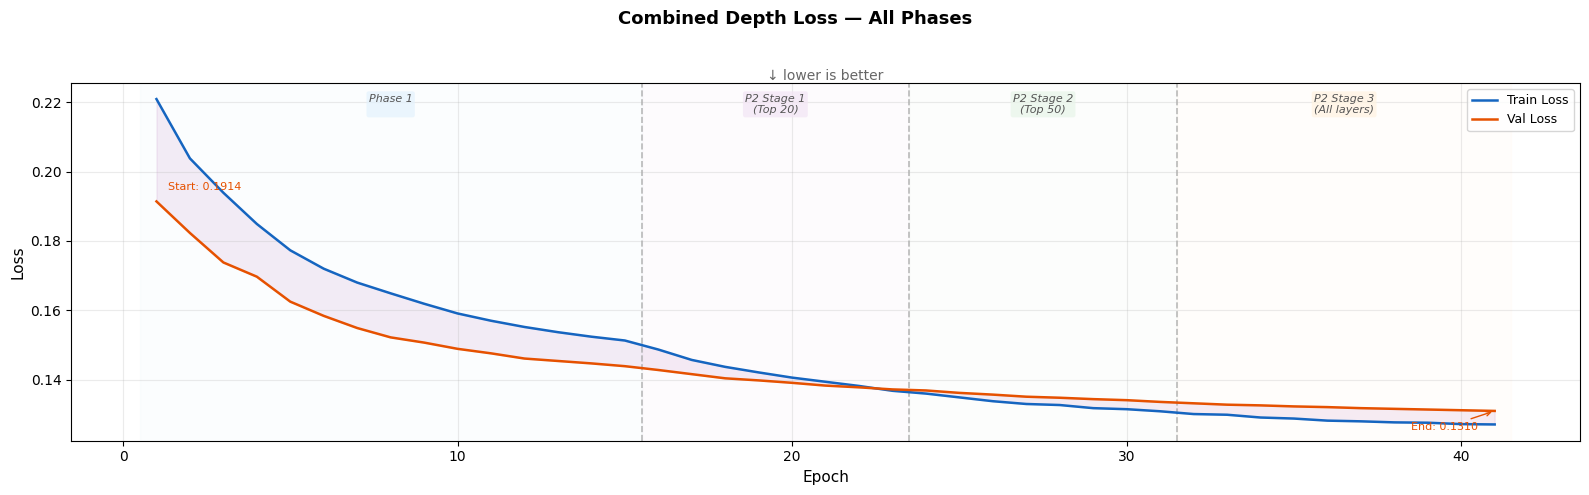

✓ Saved plot1_combined_loss.png


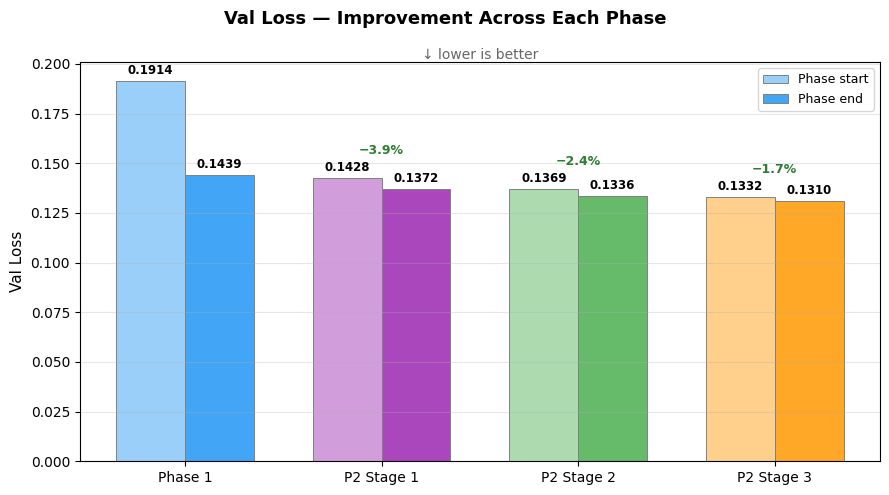

✓ Saved plot2_val_loss_per_phase.png


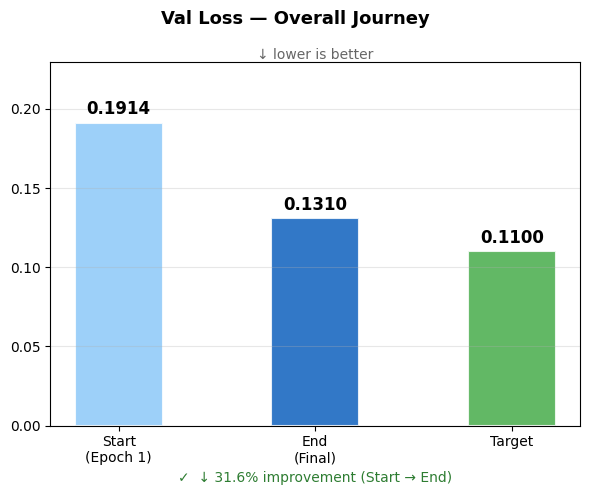

✓ Saved plot3_val_loss_overall.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

acc  = GLOBAL_HISTORY["accuracy"]
val  = GLOBAL_HISTORY["val_accuracy"]
lens = GLOBAL_HISTORY["phase_lens"]
names = GLOBAL_HISTORY["phase_names"]

epochs = np.arange(1, len(acc) + 1)

fig, ax = plt.subplots(figsize=(16,5))
fig.suptitle("Staged Fine-Tuning — Accuracy Progression",
             fontsize=14, fontweight="bold")

# Phase shading
colors = ["#E3F2FD", "#F3E5F5", "#E8F5E9", "#FFF3E0"]
pos = 0
for i, ln in enumerate(lens):
    ax.axvspan(pos+0.5, pos+ln+0.5, alpha=0.12, color=colors[i])
    pos += ln

ax.plot(epochs, acc, lw=2, label="Train Accuracy")
ax.plot(epochs, val, lw=2, label="Val Accuracy")

# Phase boundaries
pos = 0
for ln in lens[:-1]:
    pos += ln
    ax.axvline(pos+0.5, ls="--", alpha=0.6)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
fig.suptitle("Validation Accuracy Improvement Per Stage",
             fontsize=14, fontweight="bold")

start_vals = []
end_vals   = []

idx = 0
for ln in lens:
    start_vals.append(val[idx])
    end_vals.append(val[idx+ln-1])
    idx += ln

x = np.arange(len(lens))
width = 0.35

ax.bar(x - width/2, start_vals, width, label="Stage Start")
ax.bar(x + width/2, end_vals, width, label="Stage End")

for i, (s,e) in enumerate(zip(start_vals, end_vals)):
    gain = (e - s) * 100
    ax.text(i, max(s,e), f"+{gain:.1f}%",
            ha="center", va="bottom", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Validation Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

TARGET = 0.95  # change if needed

fig, ax = plt.subplots(figsize=(6,5))
fig.suptitle("Overall Accuracy Journey",
             fontsize=14, fontweight="bold")

vals = [val[0], val[-1], TARGET]
cats = ["Start", "Final", "Target"]

bars = ax.bar(cats, vals)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height()*100:.1f}%",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")

total_gain = (val[-1] - val[0]) * 100
ax.set_xlabel(f"Total Improvement: +{total_gain:.1f}%")
ax.set_ylabel("Validation Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

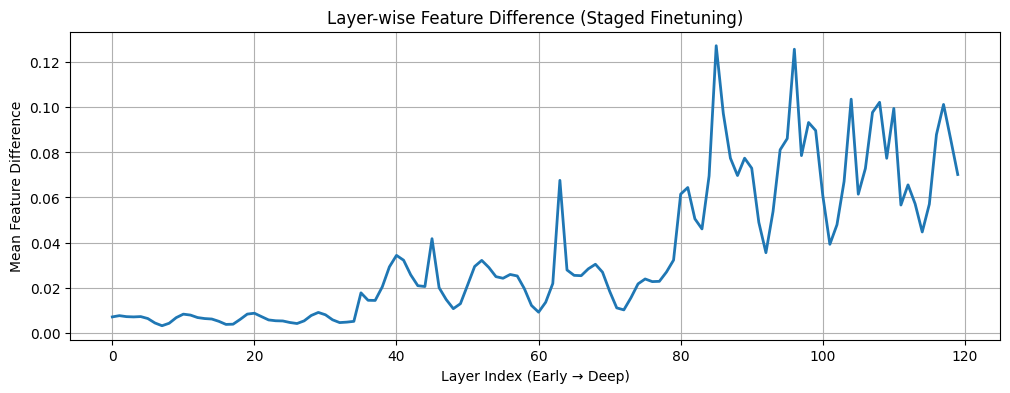

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load models
# --------------------------------------------------
normal_model = tf.keras.models.load_model("mobilenetv3small_backbone.keras", compile=False)
finetuned_model = tf.keras.models.load_model("mobilenetv3small_backbone.keras", compile=False)

# --------------------------------------------------
# Choose layer
# --------------------------------------------------
layer_name = "expanded_conv_10/project"   # change as needed

# --------------------------------------------------
# Feature extractor
# --------------------------------------------------
normal_feat_model = tf.keras.Model(
    inputs=normal_model.input,
    outputs=normal_model.get_layer(layer_name).output
)

finetuned_feat_model = tf.keras.Model(
    inputs=finetuned_model.input,
    outputs=finetuned_model.get_layer(layer_name).output
)

# --------------------------------------------------
# Load image
# --------------------------------------------------
img = tf.keras.preprocessing.image.load_img("test.jpg", target_size=(224,224))
img = tf.keras.preprocessing.image.img_to_array(img)/255.0
img = np.expand_dims(img, axis=0)

# --------------------------------------------------
# Extract features
# --------------------------------------------------
feat_normal = normal_feat_model.predict(img)
feat_finetuned = finetuned_feat_model.predict(img)

# --------------------------------------------------
# Compute channel-wise difference
# --------------------------------------------------
channel_diff = np.mean(np.abs(feat_normal - feat_finetuned), axis=(0,1,2))

# --------------------------------------------------
# Plot line graph
# --------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(channel_diff, marker='o')
plt.title("Layer-wise Feature Difference (Staged Finetuning)")
plt.xlabel("Layer Index (Early → Deep)")
plt.ylabel("Mean Feature Difference")
plt.grid(True)
plt.show()


## Cell 13 — Save Backbone

In [ ]:
# Load best weights from Stage 3
model.load_weights('/content/best_s3.keras')

# -------------------------------------------------
# Save full model
# -------------------------------------------------
model.save('/content/mobilenetv3_nyu_full.keras')
print('Saved full model: mobilenetv3_nyu_full.keras')

# -------------------------------------------------
# Save ONLY backbone weights
# -------------------------------------------------
backbone.save_weights('/content/mobilenetv3_nyu_backbone_weights.weights.h5')
print('Saved backbone weights: mobilenetv3_nyu_backbone_weights.weights.h5')

# -------------------------------------------------
# Save backbone as standalone SavedModel
# -------------------------------------------------
backbone_model = keras.Model(
    inputs=backbone.input,
    outputs=backbone.output,
    name='nyu_backbone'
)
backbone_model.save('/content/mobilenetv3_nyu_backbone')